## Ordinary Least Squares (OLS):



It is a method used in linear regression to find the best-fit line through a set of data points.


Goal :  
</b>Choose a line such that the total squared difference between actual values and predicted values is as small as possible.

The line has the form:

ŷ = c + mx

OLS helps us find the values of:

- **c** (intercept)
- **m** (slope)

so that this line fits the data in the best possible way.


### Why is it called “Least Squares”?

For each point, the model makes an error:

**error = yᵢ − ŷᵢ**

Instead of minimizing the raw errors (which can cancel out), OLS minimizes:

**Sum of Squared Errors (SSE)**  
SSE = Σ (yᵢ − ŷᵢ)²

Squaring ensures:

- Errors do not cancel out  
- Bigger mistakes get punished more  
- The line fits the majority of points well


### Steps of the OLS Approach

**Step 1: Take your x and y values**

These are your data points.

---

**Step 2: Calculate the mean of x and y**

- x_bar = average of x  
- y_bar = average of y  

---

**Step 3: Compute the slope (m)**

m = sum( (x - x_bar) * (y - y_bar) )  
      ------------------------------------------------  
      sum( (x - x_bar)^2 )

This tells you:
- how x moves,
- how y moves,
- whether they move together.

---

**Step 4: Compute the intercept (c)**

c = y_bar - m * x_bar

This anchors the line on the graph.

---

**Step 5: Build the final model**

y_hat = c + m * x

This is your regression line.

---

**Step 6: Compute individual predictions**

For each point x_i:

y_hat_i = c + m * x_i

Now you can predict values for any x.


In [15]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#### Creating  a simple dataset 

In [10]:
x = np.arange(0, 10)
y = np.arange(11, 21)   

In [14]:
df = pd.DataFrame({'x': x, 'y': y})


#### Checking the pattern

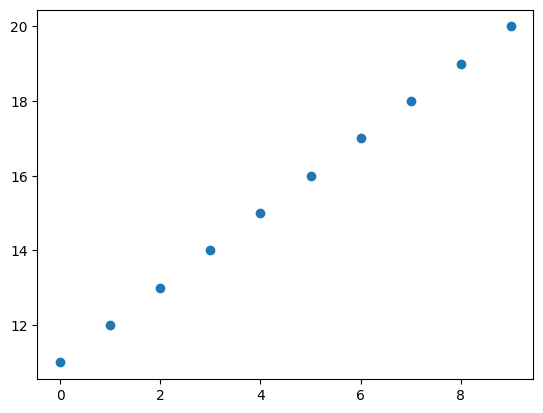

In [68]:
plt.scatter(df['x'], df['y'])

#### Calculating the y_hat

In [20]:
df['x_mean'] = df['x'].mean()
df['y_mean'] = df['y'].mean()

In [23]:
df['x - x_mean'] = df['x'] - df['x_mean']
df['y - y_mean'] = df['y'] - df['y_mean']
df['(x - x_mean)(y - y_mean)'] = df['x - x_mean']*df['y - y_mean']
df['(x - x_mean)*2'] = df['x - x_mean']*df['x - x_mean']
df.head()

,x,y,x_mean,y_mean,x - x_mean,y - y_mean,(x - x_mean)(y - y_mean),(x - x_mean)*2
0,0,11,4.5,15.5,-4.5,-4.5,20.25,20.25
1,1,12,4.5,15.5,-3.5,-3.5,12.25,12.25
2,2,13,4.5,15.5,-2.5,-2.5,6.25,6.25
3,3,14,4.5,15.5,-1.5,-1.5,2.25,2.25
4,4,15,4.5,15.5,-0.5,-0.5,0.25,0.25


In [28]:
print(f'sum of (x - x_mean)(y - y_mean), {df['(x - x_mean)(y - y_mean)'].sum()} and sum of (x - x_mean)*2 {df['(x - x_mean)*2'].sum()}')


sum of (x - x_mean)(y - y_mean), 82.5 and sum of (x - x_mean)*2 82.5


In [30]:
slope = df['(x - x_mean)(y - y_mean)'].sum()/ df['(x - x_mean)*2'].sum()
slope

np.float64(1.0)

In [32]:
intercept = (df['y'].mean()) - (slope*df['x'].mean())
intercept

np.float64(11.0)

In [33]:
y = slope*df['x'] + intercept

In [34]:
y

0    11.0
1    12.0
2    13.0
3    14.0
4    15.0
5    16.0
6    17.0
7    18.0
8    19.0
9    20.0
Name: x, dtype: float64

for x = 100 what would be y 

In [35]:
slope*100 + intercept

np.float64(111.0)

Since we have already written the code and understood each step, it makes sense to create a function for this process.  
A function saves time, avoids repeating the same calculations, and keeps the code clean and reusable.  
It also helps us maintain consistency, reduces mistakes, and allows us to run the OLS approach on any dataset quickly.


In [67]:
def ols_approach(df):
    df_new = df.copy()
    x_mean = df_new['x'].mean()
    y_mean = df_new['y'].mean()
    x_x_mean_y_y_mean = sum([(df['x'][i] - x_mean)*(df['y'][i] - y_mean) for i in range(len(df))])
    x_x_mean_2 = sum([(df['x'][i] - x_mean)**2 for i in range(len(df))])
    slope = x_x_mean_y_y_mean/x_x_mean_2
    intercept = (y_mean) - (slope)*(x_mean)
    return slope, intercept

def y_predict(df, x_new):
    slope, intercept = ols_approach(df)
    y_hat = slope*x_new + intercept
    return y_hat
    

def ols_numpy(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    return slope, intercept


def predict_numpy(x, y, x_new):
    slope, intercept = ols_numpy(x, y)
    return slope * x_new + intercept
    

In [78]:
print(f'slope and intercept {ols_approach(df)}')
print(f'predicting the y_hat for x = 201, y_hat----> {y_predict(df, 201)}')

slope and intercept (np.float64(1.0), np.float64(11.0))
predicting the y_hat for x = 201, y_hat----> 212.0


### Important Notes

- OLS gives an exact mathematical solution, unlike Gradient Descent which is iterative.
- It is fast and works very well for small to medium-sized datasets.
- It assumes that the relationship between x and y is linear.


### OLS vs Gradient Descent

| Case                         | OLS                         | Gradient Descent               |
|-----------------------------|-----------------------------|---------------------------------|
| Simple Linear Regression    | ✔ Works perfectly           | ✔ Works                         |
| Multiple Linear Regression  | ✔ Works (but slow for huge data) | ✔ Works fast              |
| Logistic Regression         | ❌ Cannot use OLS           | ✔ Works                         |
| Neural Networks             | ❌ No closed-form solution  | ✔ Only method used              |
| Big Data (Millions of rows) | ❌ Very slow                | ✔ Fast and scalable             |
| Regularization (L1, L2)     | ❌ Hard or impossible       | ✔ Works smoothly                |
| Complex models              | ❌ No formulas available    | ✔ Always works                  |


### OLS vs Gradient Descent — When to Use What

| Reason / Scenario                 | OLS (Ordinary Least Squares)          | Gradient Descent                           |
|----------------------------------|----------------------------------------|---------------------------------------------|
| Type of solution                 | ✔ Exact closed-form solution          | ✔ Approximate iterative solution            |
| Speed                            | ✔ Very fast for small/medium data     | ✔ Faster for very large datasets            |
| Tuning required                  | ✔ No tuning needed                    | ❌ Needs learning rate and iterations       |
| Computation cost                 | ❌ Expensive matrix inversion for big data | ✔ Avoids matrix inversion              |
| Interpretability                 | ✔ Simple and easy to understand       | ✔ Conceptual but less direct                |
| When relationship is linear      | ✔ Works perfectly                      | ✔ Also works                                |
| High number of features          | ❌ Slow or can break                   | ✔ Handles thousands of features easily      |
| Regularization (Lasso, Ridge)    | ❌ Hard or no closed-form solution     | ✔ Works naturally                            |
| Complex models (logistic, neural nets) | ❌ Not possible                   | ✔ Required                                   |
| When data doesn't fit in memory  | ❌ Not practical                       | ✔ Mini-batch GD works smoothly              |
| General use across ML            | ❌ Limited to linear regression        | ✔ Used everywhere in machine learning       |
